[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geo-di-lab/emerge-geoai/blob/main/docs/ch4/lesson1.ipynb)

# Vision-Language Model for GLOBE Observations

Vision-Language Models (VLMs) are AI models that can "see" images and "understand" language at the same time. This makes them perfect for participatory science, where volunteers collect photos but we need to analyze thousands of them quickly!

Today we'll use [BLIP-2](https://huggingface.co/docs/transformers/model_doc/blip-2) by Junnan Li, Dongxu Li, Silvio Savarese, and Steven Hoi to automatically describe mosquito habitat photos from NASA GLOBE Observer.

In [3]:
# Install required libraries
!pip install -q transformers torch pillow requests geopandas matplotlib
!pip install -q accelerate

# Import libraries
import geopandas as gpd
import requests
from PIL import Image
from io import BytesIO
import random
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, Blip2Processor, Blip2ForConditionalGeneration
import torch

Below, we'll load the images of mosquito habitats (water sources) from NASA GLOBE. For more information, check out [Introduction to GLOBE Data](https://geo-di-lab.github.io/emerge-lessons/docs/ch1/lesson6).

In [4]:
# Get the photo links from the GLOBE observations
mosquito = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/globe_mosquito.zip')
urls = mosquito.dropna(subset=['WaterSourcePhotoUrls'])['WaterSourcePhotoUrls']

# Get the water source types for classification labels
data = mosquito.dropna(subset=['WaterSourcePhotoUrls'])[['WaterSourcePhotoUrls', 'WaterSourceType']].copy()

print(f"\nTotal observations with photos: {len(data)}")
print(f"\nWater source types:\n{data['WaterSourceType'].value_counts()}")

# Select random samples for our demo
random.seed(42)
sample_data = data.sample(n=5).reset_index(drop=True)
print(f"\nSelected 5 random images for analysis")


Total observations with photos: 34302

Water source types:
WaterSourceType
container: artificial                                 26686
still: lake/pond/swamp                                 5111
container: natural                                     1377
flowing: still water found next to river or stream     1128
Name: count, dtype: int64

Selected 5 random images for analysis


Next, we'll load the BLIP-2 model, along with the data associated with it. The follwing code block might take a few minutes to finish loading.

In [ ]:
# Load BLIP-2 model
model_name = "Salesforce/blip2-opt-2.7b"

processor = Blip2Processor.from_pretrained(model_name)
model = Blip2ForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("BLIP-2 model loaded")

def generate_image_summary(image_url):
    """
    Takes an image URL and generates a sentence describing it.
    """
    try:
        # Handle multiple URLs separated by semicolons - take the first one
        if ';' in image_url:
            image_url = image_url.split(';')[0].strip()

        # Download the image
        response = requests.get(image_url, timeout=10)
        image = Image.open(BytesIO(response.content)).convert('RGB')

        # Generate description using BLIP-2
        prompt = "a photo of"

        # Process inputs - DON'T convert everything to float16
        inputs = processor(image, prompt, return_tensors="pt").to(model.device)

        # Generate with proper settings
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=5
        )

        summary = processor.decode(outputs[0], skip_special_tokens=True).strip()

        return image, summary

    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None, f"Error: {str(e)}"

Processing image 1/5...
Processing image 2/5...
Processing image 3/5...
Processing image 4/5...
Processing image 5/5...


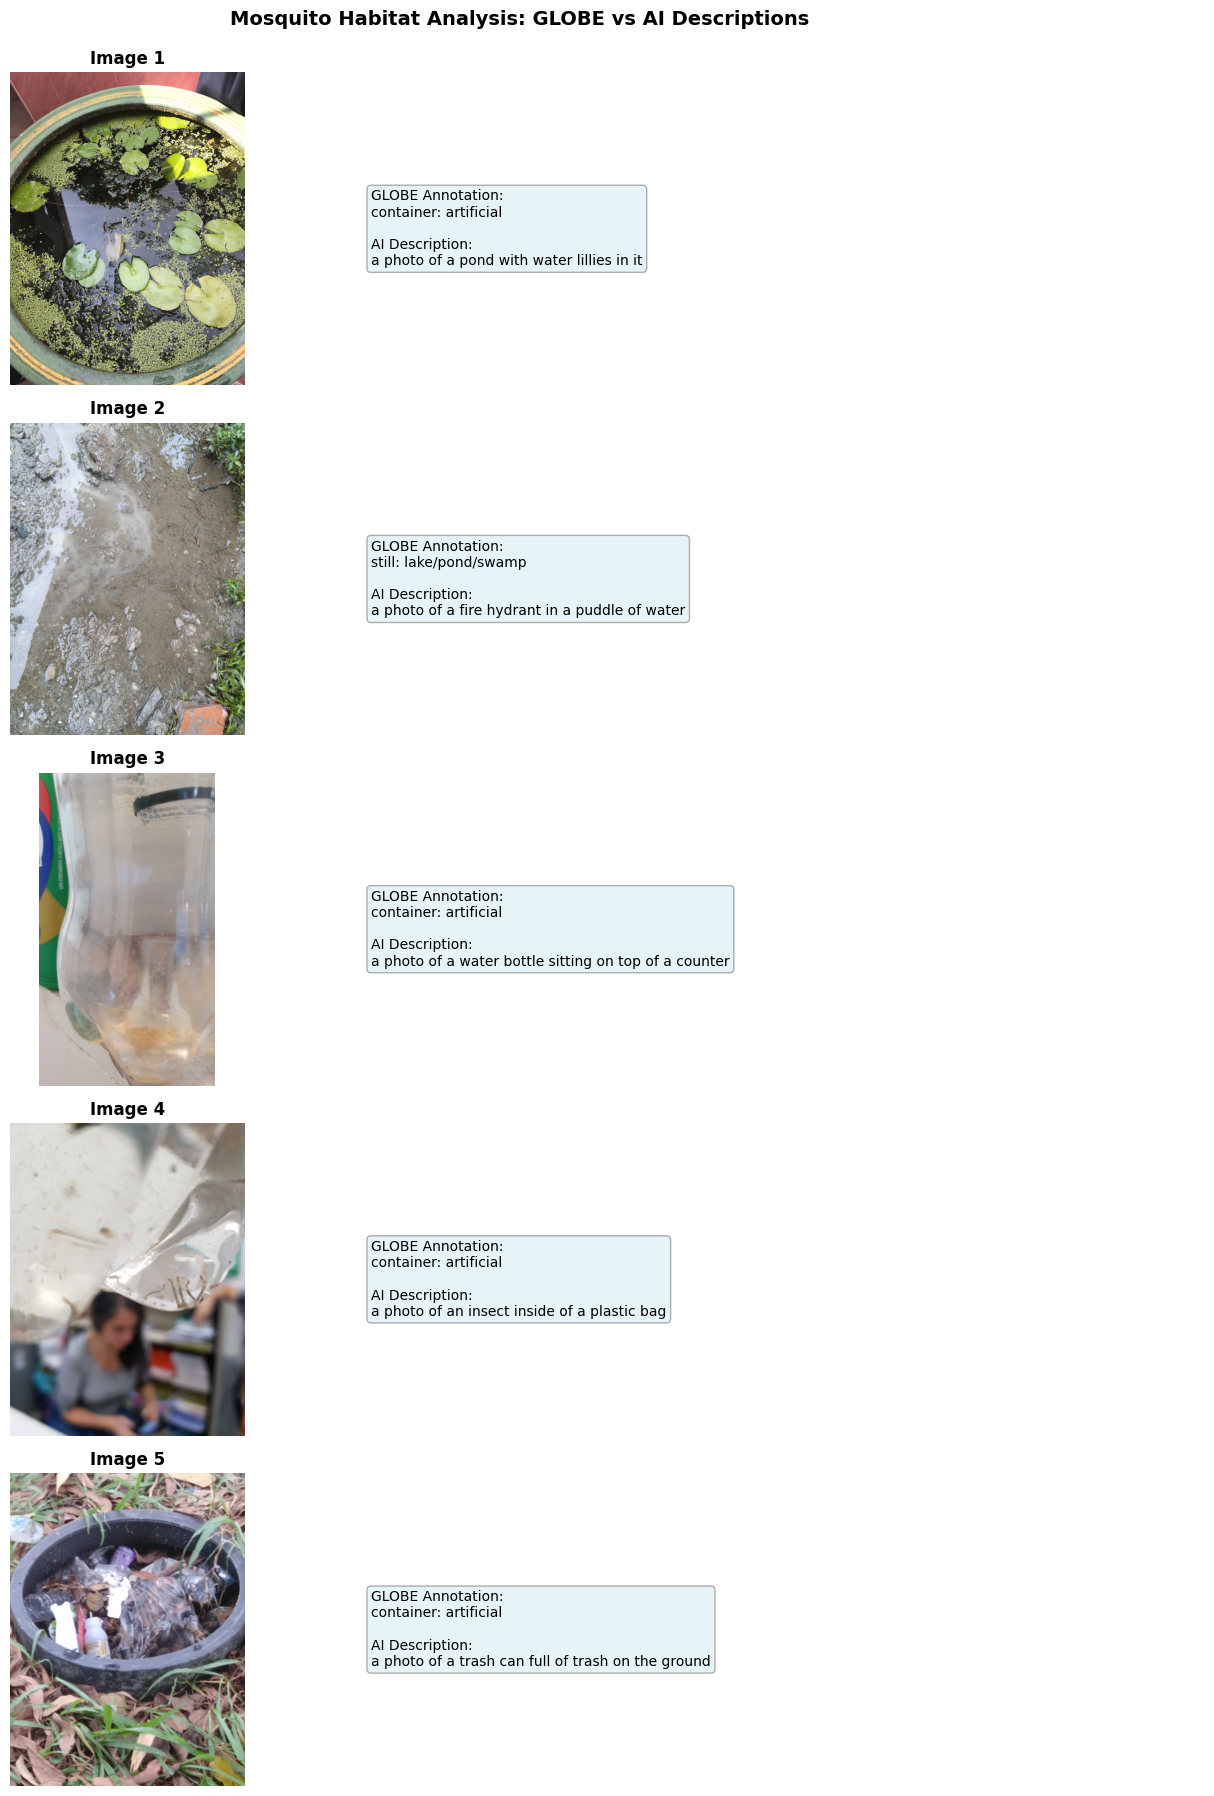

In [ ]:
# Display Results Summary with Images

# Display all results
fig, axes = plt.subplots(5, 2, figsize=(14, 18), gridspec_kw={'width_ratios': [2, 3]})

for idx, row in sample_data.iterrows():
    url = row['WaterSourcePhotoUrls']
    water_type = row['WaterSourceType']

    print(f"Processing image {idx+1}/5...")

    # Get the image and summary
    image, summary = generate_image_summary(url)

    if image is not None:
        # Left column: Display the image
        axes[idx, 0].imshow(image)
        axes[idx, 0].axis('off')
        axes[idx, 0].set_title(f"Image {idx+1}", fontsize=12, fontweight='bold')

        # Right column: Display the captions as text
        axes[idx, 1].axis('off')

        # Create caption text
        caption_text = f"GLOBE Annotation:\n{water_type}\n\n"
        caption_text += f"AI Description:\n{summary}"

        axes[idx, 1].text(0.05, 0.5, caption_text,
                         fontsize=10,
                         verticalalignment='center',
                         wrap=True,
                         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    else:
        # Handle error case
        axes[idx, 0].text(0.5, 0.5, "Image could not be loaded",
                         ha='center', va='center')
        axes[idx, 0].axis('off')
        axes[idx, 1].text(0.5, 0.5, summary,
                         ha='center', va='center', wrap=True, color='red')
        axes[idx, 1].axis('off')

plt.suptitle('Mosquito Habitat Analysis: GLOBE vs AI Descriptions',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('mosquito_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()

We can see that the generated descriptions are generally accurate to the image, though some elements may be mis-identified like the fire hydrant or trash can. This workflow can be very useful for processing many images at once and seeing what features repeatedly show up by searching for key terms in the descriptions.

We used BLIP-2 for this example because it is faster and more light-weight than other models. There are many more [vision-language models](https://huggingface.co/spaces/opencompass/open_vlm_leaderboard) that can be applied to find patterns in participatory science images.